# fastelo: a chess bot that plays at your level, and a network that rates you as you play

**Isaí Roberto Sotarriva Álvarez**

Two questions drive this project:

1. Can a neural network play chess *like a human of a chosen rating*, from 600 to about 2400 Elo?
2. Can the strength of a player be read from a game move by move, with an honest error bar, in
   one game instead of the dozens a rating system needs?

This notebook is the report of what was built and measured. It replaces the prototype in
`ChessFastElo-2.ipynb`, which sketched the idea with toy models. The code is now a Python package;
the notebook only loads results and plots them.

| | |
|---|---|
| Play against it | [live demo](https://presonal-page-eight.vercel.app/en/projects/fast-elo-estimation-for-chess) |
| Code | [github.com/irsotarriva/fastelo](https://github.com/irsotarriva/fastelo) (GPL-3.0) |
| Trained models | [huggingface.co/irsotarriva/fastelo](https://huggingface.co/irsotarriva/fastelo) |
| Synthetic games dataset | [fastelo-synthetic-games](https://huggingface.co/datasets/irsotarriva/fastelo-synthetic-games) (CC0) |
| This notebook | [github.com/irsotarriva/MLIdeas](https://github.com/irsotarriva/MLIdeas) |

## Summary

- **Two transformers of about 7M parameters each**: a *player* (policy network conditioned on
  rating) and a *strong player* (distilled from Leela Chess Zero, mixed in at the top of the
  range).
- **The player matches human move quality from 600 to about 2400 Elo** after a calibration step
  that needs no training. Above about 2400 to 2500 it cannot get stronger.
- **The same player rates you.** How likely your moves are under the player at each rating is a
  measurement of your rating that depends only on your own moves. Its bias is measured on real
  players and corrected, and what is left is quoted as a systematic error. One game of 20 moves
  gives about ±300 Elo; five games about ±60 to 150.
- **A separate rating network was trained first and dropped.** It mostly read the level of the
  game, so against a bot that follows the estimate it drifted. Section 7 shows the measurement.
- Training took about 33 hours on a single RTX 3090; the demo needs no GPU.

In [1]:
import json, sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# The fastelo package (github.com/irsotarriva/fastelo) is a submodule of MLIdeas.
ROOT = next(p for p in (Path("fastelo"), Path("."), Path("..")) if (p / "results" / "calibration.json").exists())
sys.path.insert(0, str(ROOT.resolve()))
R = lambda name: json.load(open(ROOT / "results" / name))

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})
BLUE, ORANGE, GREY, GREEN = "#2E86C1", "#D9822B", "#5D6D7E", "#3c9d6b"
logs = R("training_logs.json")
val = lambda name: [r for r in logs[name] if r.get("split") == "val"]

## 1. Data

All human data comes from the [Lichess open database](https://database.lichess.org/) (CC0): rated
**rapid and classical** games from August to November 2025. Games with bots, provisional ratings
or abandoned in the opening are removed, which leaves 42.7 million games. Rapid and classical were
chosen because blitz and bullet ratings measure speed as much as chess.

Each position is stored in 29 bytes, always from the point of view of the player to move (black
positions are mirrored), so the networks never need to learn the game twice. Moves are indices into
a fixed vocabulary of the 1880 moves a player can make from that point of view.

In [2]:
import chess
from fastelo.vocab import MOVES, VOCAB_SIZE, encode_move

print("vocabulary size:", VOCAB_SIZE, "| first entries:", MOVES[:6], "| promotions:", [m for m in MOVES if len(m) == 5][:4])
board = chess.Board()
print("1. e4 for white ->", encode_move(chess.Move.from_uci("e2e4"), chess.WHITE),
      "| 1... e5 for black is the same index (mirrored):", encode_move(chess.Move.from_uci("e7e5"), chess.BLACK))

vocabulary size: 1880 | first entries: ['a1a2', 'a1a3', 'a1a4', 'a1a5', 'a1a6', 'a1a7'] | promotions: ['a7a8b', 'a7a8n', 'a7a8q', 'a7a8r']
1. e4 for white -> 979 | 1... e5 for black is the same index (mirrored): 979


## 2. Models

- **Player.** 64 square tokens (piece + square embedding) plus three context tokens: one summary
  token that also carries the time control, the mover's rating and the opponent's rating. Eight
  pre-norm transformer layers, width 256. The summary token is decoded into a distribution over
  the 1880 moves. Ratings enter through embeddings learned at knots every 100 Elo and
  interpolated in between, so the conditioning is continuous.
- **Strong player.** The same architecture before the human phase (section 3). Above a target
  of about 2100 its move distribution is mixed into the player's.

In [3]:
import torch
from fastelo.models import Actor, ActorConfig

count = lambda m: sum(p.numel() for p in m.parameters())
print(f"player: {count(Actor(ActorConfig())) / 1e6:.2f}M parameters (the strong player has the same size)")

player: 6.93M parameters (the strong player has the same size)


## 3. Training the player in two stages

**Stage 1, distillation.** A network trained only on human moves learns human mistakes at every
level, and has no notion of what a good move is beyond what strong humans happen to play. So the
player first learns chess from an engine: it is trained to reproduce the move distribution and the
win/draw/loss output of the Leela Chess Zero network `T1-256x10-distilled-swa-2432500` on 300
million positions. The positions come from real Lichess games, never from engine self-play, so
that the student sees the positions humans actually reach. This student is the *strong player*.

**Stage 2, human phase.** Starting from the student, the network is trained on 500 million
positions to predict the move the human played, given both ratings.

Optimiser: Muon for the weight matrices and AdamW for the rest, bfloat16 autocast.

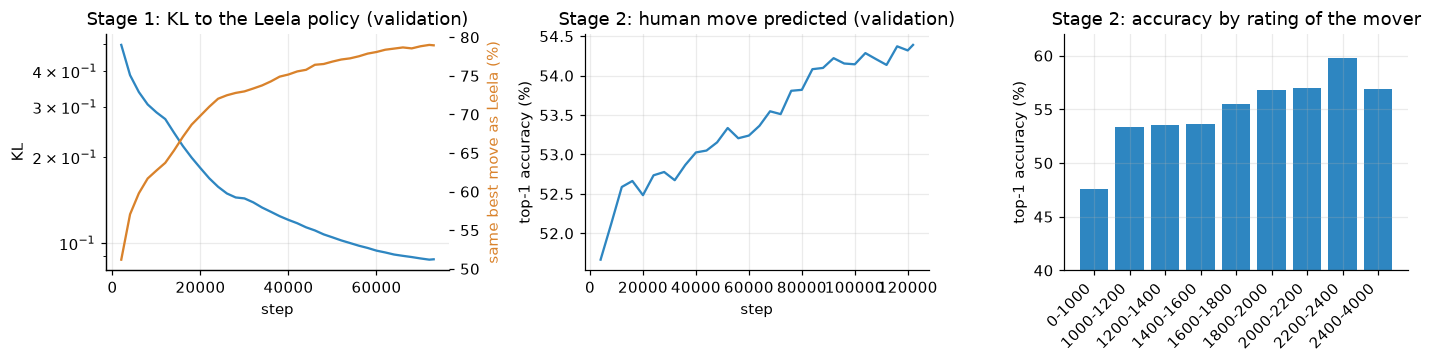

distillation: KL 0.088, same best move as Leela 79.0%, expected-score loss of its best move 1.65% per move (Stockfish)
human phase:  top-1 54.4% after 122,000 steps


In [4]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
d = val("distill")
ax[0].plot([r["step"] for r in d], [r["kl"] for r in d], color=BLUE)
ax[0].set(title="Stage 1: KL to the Leela policy (validation)", xlabel="step", ylabel="KL", yscale="log")
a2 = ax[0].twinx(); a2.grid(False)
a2.plot([r["step"] for r in d], [100 * r["top1_agree"] for r in d], color=ORANGE)
a2.set_ylabel("same best move as Leela (%)", color=ORANGE)
p = val("player")
ax[1].plot([r["step"] for r in p], [100 * r["top1"] for r in p], color=BLUE)
ax[1].set(title="Stage 2: human move predicted (validation)", xlabel="step", ylabel="top-1 accuracy (%)")
bands = p[-1]["top1_by_elo"]
ax[2].bar(range(len(bands)), [100 * v for v in bands.values()], color=BLUE)
ax[2].set_xticks(range(len(bands))); ax[2].set_xticklabels(bands.keys(), rotation=45, ha="right")
ax[2].set(title="Stage 2: accuracy by rating of the mover", ylabel="top-1 accuracy (%)", ylim=(40, 62))
fig.tight_layout(); plt.show()
print(f"distillation: KL {d[-1]['kl']:.3f}, same best move as Leela {100 * d[-1]['top1_agree']:.1f}%, "
      f"expected-score loss of its best move {100 * d[-1]['strength']['argmax_loss']:.2f}% per move (Stockfish)")
print(f"human phase:  top-1 {100 * p[-1]['top1']:.1f}% after {p[-1]['step']:,} steps")

### Does the rating input mean anything?

For held-out games, the mover's rating input is swept and the likelihood of the moves actually
played is recorded. If the conditioning works, games of 1200-rated players are most likely under an
input near 1200, and so on.

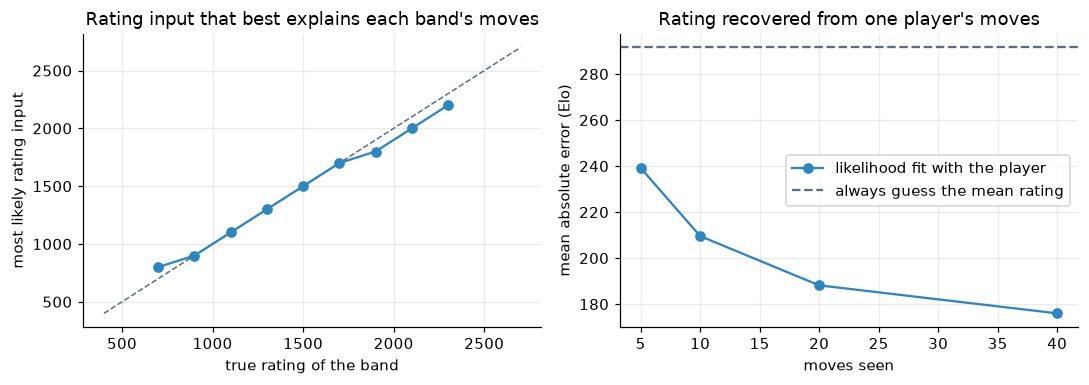

correlation between band and best input: 0.998; top-1 at the true rating: 53.9%


In [5]:
lik = R("player_likelihood.json")
c = [b["center"] for b in lik["bands"]]; a = [b["argmax_elo"] for b in lik["bands"]]
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].plot([400, 2700], [400, 2700], color=GREY, ls="--", lw=1)
ax[0].plot(c, a, "o-", color=BLUE)
ax[0].set(title="Rating input that best explains each band's moves", xlabel="true rating of the band", ylabel="most likely rating input")
pr = lik["player_recovery"]
n = [5, 10, 20, 40]
ax[1].plot(n, [pr[f"mae_{k}_moves"] for k in n], "o-", color=BLUE, label="likelihood fit with the player")
ax[1].axhline(pr["baseline_prior_mean_mae"], color=GREY, ls="--", label="always guess the mean rating")
ax[1].set(title="Rating recovered from one player's moves", xlabel="moves seen", ylabel="mean absolute error (Elo)"); ax[1].legend()
fig.tight_layout(); plt.show()
print(f"correlation between band and best input: {lik['band_peak_corr']:.3f}; top-1 at the true rating: {100 * lik['top1_true_elo']:.1f}%")

## 4. Is it as strong as it claims? Calibration without training

Predicting human moves well does not guarantee playing at the right *strength*. Strength is
measured here as the **expected-score loss per move**: 30,000 held-out positions are analysed with
Stockfish, and each move is charged the winning chances it gives away. Humans of each rating band
have a characteristic loss; the player should have the same one when asked for that rating.

The raw network gets the trend right but not the level, and it stops improving at about 2400.
Rather than train again, a calibration maps a *target* rating to three settings:

- the **rating input** (a small correction, at most a few hundred Elo);
- the **temperature** of the move distribution: two straight segments, nearly flat at low ratings
  and falling above 1650;
- the **share of the strong player**, which rises from 0 at 2100 to 1 at 2500.

Temperature and mixing absorb most of the difference; the correction of the rating input is the
small remainder. All three are fitted on the Stockfish-analysed positions, by inference only.

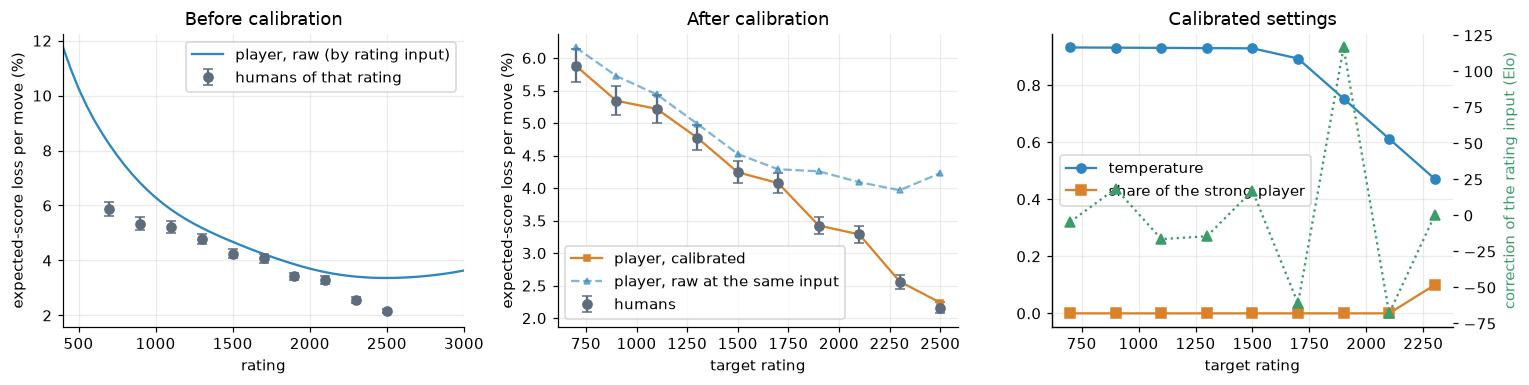

target -> human loss / calibrated loss (% per move):
  700: 5.88/5.88  900: 5.34/5.34  1100: 5.22/5.22  1300: 4.77/4.77  1500: 4.24/4.24  1700: 4.08/4.08  1900: 3.42/3.42  2100: 3.29/3.29  2300: 2.56/2.56  2500: 2.16/2.24


In [6]:
st, cal = R("player_strength.json"), R("calibration.json")
e = np.array([float(k) for k in st["expected_loss_vs_elo"]]); l = np.array(list(st["expected_loss_vs_elo"].values()))
cb = cal["bands"]
x = [b["elo"] for b in cb]
fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
ax[0].plot(e, 100 * l, color=BLUE, label="player, raw (by rating input)")
ax[0].errorbar(x, [100 * b["human"] for b in cb], yerr=[100 * b["human_se"] for b in cb], fmt="o", color=GREY, capsize=3, label="humans of that rating")
ax[0].set(title="Before calibration", xlabel="rating", ylabel="expected-score loss per move (%)", xlim=(400, 3000)); ax[0].legend()
ax[1].errorbar(x, [100 * b["human"] for b in cb], yerr=[100 * b["human_se"] for b in cb], fmt="o", color=GREY, capsize=3, label="humans")
ax[1].plot(x, [100 * b["policy_loss"] for b in cb], "s-", color=ORANGE, ms=4, label="player, calibrated")
ax[1].plot(x, [100 * b["raw_loss"] for b in cb], "^--", color=BLUE, ms=4, alpha=0.6, label="player, raw at the same input")
ax[1].set(title="After calibration", xlabel="target rating", ylabel="expected-score loss per move (%)"); ax[1].legend()
k = [q for q in cal["knots"] if q["conditioning"] is not None]
ax[2].plot([q["elo"] for q in k], [q["temperature"] for q in k], "o-", color=BLUE, label="temperature")
ax[2].plot([q["elo"] for q in k], [q["mix"] for q in k], "s-", color=ORANGE, label="share of the strong player")
ax[2].set(title="Calibrated settings", xlabel="target rating"); ax[2].legend()
a3 = ax[2].twinx(); a3.grid(False)
a3.plot([q["elo"] for q in k], [q["conditioning"] - q["elo"] for q in k], "^:", color=GREEN, label="correction of the rating input")
a3.set_ylabel("correction of the rating input (Elo)", color=GREEN)
fig.tight_layout(); plt.show()
print("target -> human loss / calibrated loss (% per move):")
print("  " + "  ".join(f"{b['elo']:.0f}: {100 * b['human']:.2f}/{100 * b['policy_loss']:.2f}" for b in cb))

The calibrated player matches the human loss in every band it can reach. In the highest band the
match is within about one standard error of the human measurement; beyond it the player cannot
go, because near the top it is already the strong player choosing close to its best move.

## 5. Rating you from your own moves

The player gives p(move | position, rating). Turn that around: for the moves one person actually
played, how likely are they at each rating? Summed over the moves, the log-probability as a
function of the rating input is a measurement of that person's rating, and it uses nothing but
their own decisions.

In practice every move is scored under 12 rating inputs from 400 to 2600. The scores are added
up move by move, the curve is interpolated, and its mean and width are the estimate and its
uncertainty. Two details come from testing on real players:

- **A cap on what one move can say.** A single blunder has almost zero probability for a strong
  player and would decide the whole estimate, so no move may count for more than 4 nats against
  any rating. On real games the accuracy with and without the cap is the same; the cap is there
  for the mouse slip, which is not information about your chess.
- **The mean of the curve, not its peak.** Maximum likelihood is clearly worse, especially early.

More elaborate versions (an explicit outlier model, with its rate fixed, fitted per player or
averaged over) were tried on 3,300 real players and none beat the plain sum:

In [7]:
study = R("rating_study.json")
print(f"{'variant':<46}{'error after 10 / 20 / 40 own moves':>36}{'90th pct. at 20':>18}")
for r in study["variants"]["rows"]:
    print(f"{r['name']:<46}{' / '.join(str(x) for x in r['mae']):>36}{r['p90_20']:>18}")

variant                                         error after 10 / 20 / 40 own moves   90th pct. at 20
sum of log-probabilities, posterior mean                           243 / 190 / 158               405
with a cap of 4 nats per move (used)                               246 / 191 / 158               404
maximum likelihood instead of the mean                             275 / 209 / 170               447
outlier model, 2% random moves                                     248 / 193 / 159               407
outlier model, 5%                                                  252 / 195 / 159               414
outlier model, 10%                                                 258 / 199 / 160               426
outlier rate fitted per player                                     263 / 200 / 160               424
outlier rate marginalised                                          258 / 198 / 159               420


## 6. Bias and error bars

Any estimate of a noisy quantity is pulled toward the middle of the scale, this one included:
after a few moves the curve is wide and its mean sits near 1500 whoever is playing. This is the
same problem as a detector whose response is not linear: measure the response, invert it, and
quote what the inversion cannot remove.

1. **Measure.** 300 players in every 200-Elo band from 400 to 2600 (so the tails are as well
   measured as the middle), on held-out human games; record the estimate and its width after 3,
   5, 8, 10, 15, 20, 30 and 40 of their own moves.
2. **Correct.** For each number of moves, find a monotone map *f* such that the mean of
   *f(estimate)* equals the true rating at every true rating. This is unbiased by construction.
3. **Statistical error.** The estimate plus and minus its width, mapped through *f*. The result is
   asymmetric. The width is first scaled by a factor fitted on the same data (between 0.7 and
   1.2): successive moves are not quite independent, so the raw curve is a little too narrow in
   long games.
4. **Systematic error.** The bias that remains on an *independent* set of games (the closure
   test). It is common to all games of a player, so it does not shrink when games are combined.

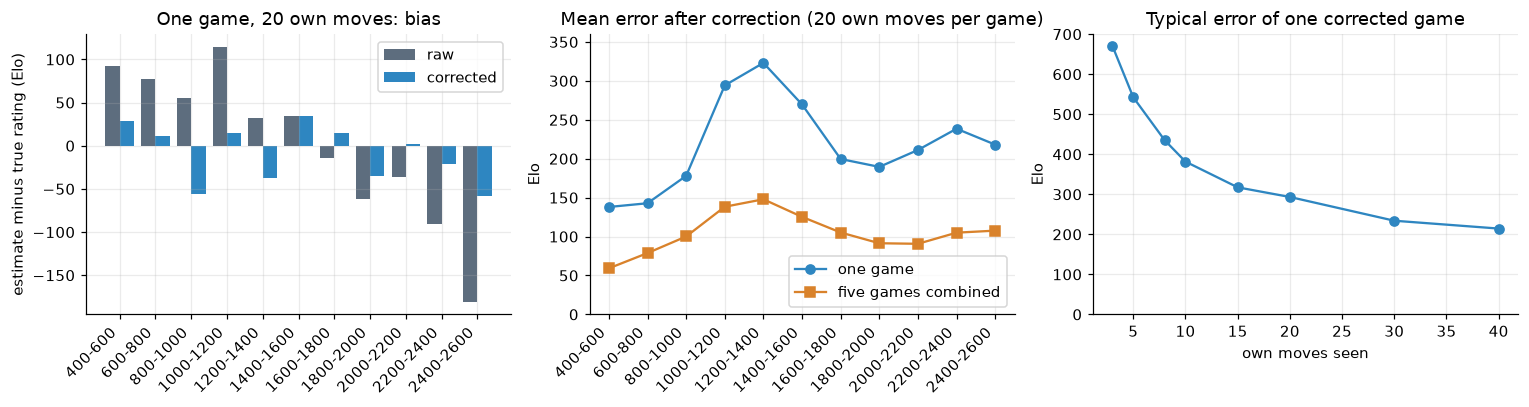

true rating   stat. error after 20 moves  inside 1 sigma  systematic  error of 1 game  of 5 games
400-600                      -137 / +127             57%          32              138          59
600-800                      -168 / +149             58%          19              143          79
800-1000                     -170 / +218             49%          59              178         100
1000-1200                    -258 / +302             56%          28              294         138
1200-1400                    -303 / +316             61%          45              323         148
1400-1600                    -360 / +300             69%          40              270         125
1600-1800                    -326 / +270             68%          22              200         105
1800-2000                    -289 / +289             70%          39              190          91
2000-2200                    -263 / +300             66%          17              211          91
2200-2400           

In [8]:
resp = R("rating_response.json")
raw, cor, cmb = resp["closure"]["40"]["raw"], resp["closure"]["40"]["corrected"], resp["combined"]["40"]
x = np.arange(len(raw)); names = [r["band"] for r in raw]
fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
ax[0].bar(x - 0.2, [r["bias"] for r in raw], 0.4, color=GREY, label="raw")
ax[0].bar(x + 0.2, [r["bias"] for r in cor], 0.4, color=BLUE, label="corrected")
ax[0].set(title="One game, 20 own moves: bias", ylabel="estimate minus true rating (Elo)"); ax[0].legend()
ax[0].set_xticks(x); ax[0].set_xticklabels(names, rotation=45, ha="right")
ax[1].plot(x, [r["mae"] for r in cor], "o-", color=BLUE, label="one game")
ax[1].plot(x, [r["mae"] for r in cmb], "s-", color=ORANGE, label="five games combined")
ax[1].set(title="Mean error after correction (20 own moves per game)", ylabel="Elo", ylim=(0, 360)); ax[1].legend()
ax[1].set_xticks(x); ax[1].set_xticklabels(names, rotation=45, ha="right")
ax[2].plot(np.array(resp["plies"]) / 2, resp["resolution"], "o-", color=BLUE)
ax[2].set(title="Typical error of one corrected game", xlabel="own moves seen", ylabel="Elo", ylim=(0, 700))
fig.tight_layout(); plt.show()
print(f"{'true rating':<11} {'stat. error after 20 moves':>28} {'inside 1 sigma':>15} {'systematic':>11} {'error of 1 game':>16} {'of 5 games':>11}")
for r, c5 in zip(cor, cmb):
    print(f"{r['band']:<11} {'-%.0f / +%.0f' % (r['mean_minus'], r['mean_plus']):>28} {100 * r['coverage']:>14.0f}% {resp['systematic']['40'][r['band']]:>11.0f} {r['mae']:>16.0f} {c5['mae']:>11.0f}")

What the closure test says:

- After correction the bias is within about 60 Elo in every band. With about 200 to 280 players
  per band it is known to about 15 to 25 Elo, so part of what is left is noise of the test itself.
- One game is a weak measurement: about ±300 Elo after 20 of your moves and about ±200 after 40.
  Five games bring the mean error to roughly 60 to 150 Elo.
- In the lowest bands the one-sigma interval holds only 50 to 60% of the true ratings where 68%
  is expected: the error bars are somewhat too narrow there.
- When several games are combined, each is weighted by the typical error of a game of its length
  and not by its own error bar, because weights that depend on the estimate bias the average.

**Reporting range.** The demo quotes ratings only between **600 and 2200**. Below 600 the player
is not calibrated; near the top, play generated by the bot itself is rated 100 to 200 Elo too
high. Outside the range the demo says "below 600" or "2200+" and gives no number.

## 7. What was tried first: a separate rating network

The original plan, and the first notebook, had two networks: the player and a separate *Elo
estimator*, a causal transformer that reads the whole game and predicts both players' ratings
after every move. It was trained and looked good on human games, with about 190 Elo of error
after a game. It is not part of the result, for one decisive reason and two lesser ones.

**It reads the level of the game, not the player.** In human games the two players are matched,
so how well the *opponent* plays gives the rating away, and the network learned to use that. In
the demo the opponent is a bot whose strength follows the estimate, so the reasoning is
circular: the bot drops a little, plays worse, the estimate follows it down, and so on. A user
playing the engine's best moves was rated below 700 after twenty moves.

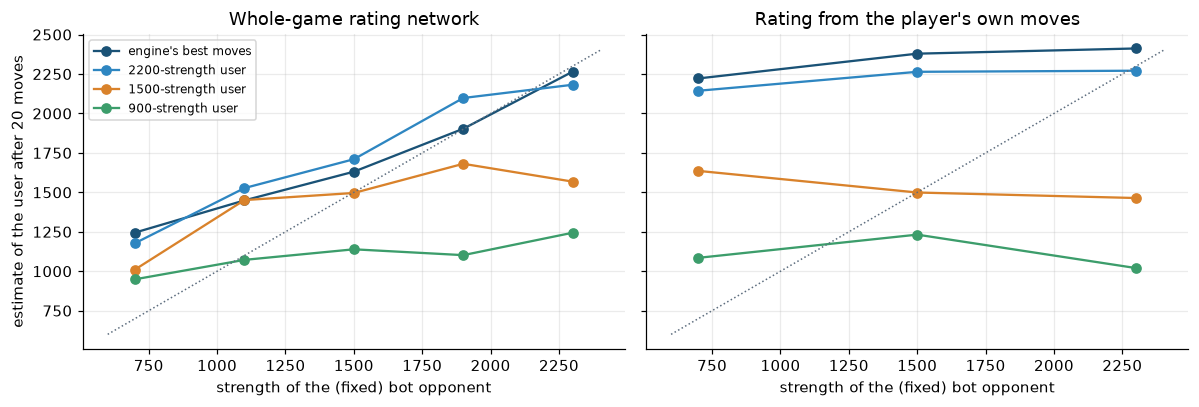

bot following the rating, simulated users of known strength:
  own-moves rating, after 2 games:  700->778  1000->1008  1300->1352  1600->1653  1900->2087  2200->2404
  whole-game network, after 3 games (bot re-targets every move / fixed per game / slowly):
    user best: 1569 / 1509 / 1459
    user 2200: 2151 / 2022 / 1806
    user 1500: 1683 / 1466 / 1412
    user  900: 969 / 1078 / 947


In [9]:
e, m = study["estimator_vs_fixed_bot"], study["move_rating_vs_fixed_bot"]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
cols = {"best": "#1A5276", "2200": BLUE, "1500": ORANGE, "900": GREEN}
for a, d, title in ((ax[0], e, "Whole-game rating network"), (ax[1], m, "Rating from the player's own moves")):
    for u, c in cols.items():
        a.plot(d["bot"], d["user"][u], "o-", color=c, label="engine's best moves" if u == "best" else f"{u}-strength user")
    a.plot([600, 2400], [600, 2400], color=GREY, ls=":", lw=1)
    a.set(title=title, xlabel="strength of the (fixed) bot opponent")
ax[0].set_ylabel("estimate of the user after 20 moves"); ax[0].legend(fontsize=8)
fig.tight_layout(); plt.show()
cl, ecl = study["move_rating_closed_loop"], study["estimator_closed_loop"]
print("bot following the rating, simulated users of known strength:")
print("  own-moves rating, after 2 games:  " + "  ".join(f"{t}->{v}" for t, v in zip(cl["target"], cl["corrected_after_2"])))
print("  whole-game network, after 3 games (bot re-targets every move / fixed per game / slowly):")
for u, v in ecl["user"].items():
    print(f"    user {u:>4}: " + " / ".join(str(x) for x in v))

On the left every line climbs with the opponent: the same user is rated a thousand Elo apart
depending on who they face. On the right the lines are flat. Slowing the bot down (a controller
that follows the estimate with a delay, as in the first notebook) stops the collapse but not the
dependence: a best-move user still ends near 1500.

The two lesser reasons:

- **It over-weights the opening.** Synthetic players with separate strengths for the opening,
  the middlegame and the endgame were rated by results on a ladder against bots of known
  strength. In results the opening is worth about a fifth of the rating; the network gave it
  nearly half. Games of such players are published as a [dataset](https://huggingface.co/datasets/irsotarriva/fastelo-synthetic-games).
- **It is no more accurate.** On the same real players the rating from the player's own moves has
  less shrinkage and, after correction, the same or a smaller error, without using the opponent
  at all.

Reading the rating from the player has one more advantage: every move is scored on its own, so
the curve shows where in a game you played above or below your level.

## 8. Try it

The models are on Hugging Face. The cell below downloads them, lets the bot play both sides of
five games at 1500, and rates white from its own moves as each game goes on. `rating()` applies
the bias correction and returns the value, the asymmetric statistical bounds and the systematic
error. Single games scatter by a few hundred Elo, as the error bars say; the combination is the
number to read.

game 1: 1. e4 e5 2. Nf3 Nc6 3. d4 exd4 4. c3 dxc3 5. Bc4 Qe7 6. Nxc3 d6 7. O-O Be6 8. Nd5 Bxd5 9. exd5 Ne5 10. Nxe5 Qxe5 ...
game 1, after 40 moves: 2097 -403/+429 (stat)


game 2, after 40 moves: 1313 -211/+249 (stat)


game 3, after 29 moves: 1756 -458/+471 (stat)


game 4, after 37 moves: 2066 -283/+243 (stat)


game 5, after 38 moves: 1294 -160/+188 (stat)


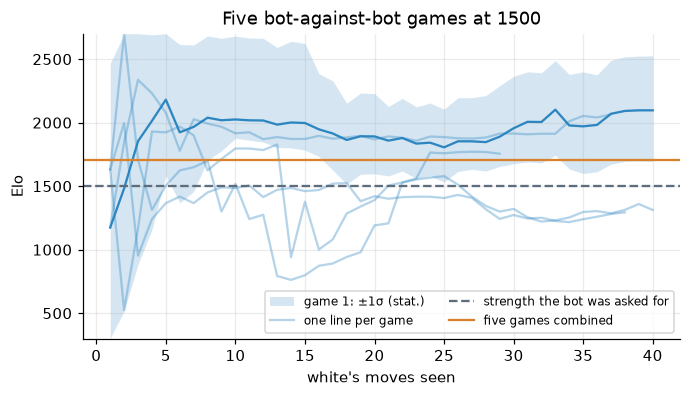

five games combined: 1702 -140/+146 (stat) ±26 (syst)


In [10]:
import contextlib, io, os, warnings
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
warnings.filterwarnings("ignore")
from IPython.display import display
with contextlib.redirect_stderr(io.StringIO()):   # keep download messages out of the report
    from huggingface_hub import snapshot_download
    root = snapshot_download("irsotarriva/fastelo")
from fastelo.play import Player, Rater

bot = Player(f"{root}/calibration.json")
rater = Rater(bot, response=f"{root}/rating_response.json")

from fastelo import response as R_
rng = np.random.default_rng(7)
fig, ax = plt.subplots(figsize=(7, 3.6))
games = []
for g in range(5):   # five games, bot against bot, both asked to play at 1500; white is the one rated
    board, boards, moves = chess.Board(), [], []
    while not board.is_game_over() and len(moves) < 80:
        m = bot.choose(board, len(moves), 1500, 1500, rng)
        boards.append(board.copy(stack=False)); moves.append(m); board.push(m)
    r = rater.rating(boards, moves, side=0)
    n = np.arange(1, len(r["value"]) + 1)
    if g == 0:
        print("game 1:", chess.Board().variation_san(moves[:20]), "...")
        ax.fill_between(n, r["lo"], r["hi"], color=BLUE, alpha=0.2, lw=0, label="game 1: ±1σ (stat.)")
    ax.plot(n, r["value"], color=BLUE, alpha=1.0 if g == 0 else 0.35, label="one line per game" if g == 1 else None)
    games.append((r["value"][-1], r["value"][-1] - r["lo"][-1], r["hi"][-1] - r["value"][-1], r["resolution"][-1], r["syst"][-1]))
    print(f"game {g + 1}, after {len(n)} moves: {games[-1][0]:.0f} -{games[-1][1]:.0f}/+{games[-1][2]:.0f} (stat)")
v, lo, hi, res, syst = map(np.array, zip(*games))
value, minus, plus = R_.combine(v, lo, hi, res)
ax.axhline(1500, color=GREY, ls="--", label="strength the bot was asked for")
ax.axhline(value, color=ORANGE, label="five games combined")
ax.set(xlabel="white's moves seen", ylabel="Elo", ylim=(300, 2700), title="Five bot-against-bot games at 1500"); ax.legend(fontsize=8, ncol=2)
display(fig); plt.close(fig)
print(f"five games combined: {value:.0f} -{minus:.0f}/+{plus:.0f} (stat) ±{syst.mean():.0f} (syst)")

In the [demo](https://presonal-page-eight.vercel.app/en/projects/fast-elo-estimation-for-chess) the same thing happens against you: the game is timed (the player learned
from rapid games, and unlimited thinking time would flatter you), every game, finished or not, is
one measurement, and the bot re-targets your current best estimate before each of its moves.

## 9. Compute

Everything ran on a single RTX 3090 (24 GB), in bfloat16:

| Step | Amount | Time |
|---|---|---|
| Labelling positions with the Leela teacher | 300 million positions | about 6 hours |
| Distillation (strong player) | 73,000 steps of 4,096 positions | about 10 hours |
| Human phase (player) | 122,000 steps of 4,096 positions | about 17 hours |

The calibration and the bias correction of the rating are inference only and were done on a
desktop CPU. Playing needs no GPU either: on one CPU core a bot move takes about 30 ms and an
update of the rating (12 passes of the player per move) about 300 ms, which is what lets the demo
run in a small serverless function.

## 10. Limitations

- The player cannot exceed about 2400 to 2500, and near the top it is mostly the engine-distilled
  network, which is less human-like.
- One game is a weak measurement: about ±300 Elo after 20 of your moves.
- Error bars are somewhat too narrow for players below about 1200.
- Play generated by the bot itself is rated 100 to 200 Elo too high near the top of the range.
- Ratings are on the Lichess rapid scale and are only quoted between 600 and 2200.
- Ratings from untimed or blitz play are not calibrated.

## Licence and attribution

Code and weights: GNU GPL v3.0. Synthetic games: CC0.

- Data: [Lichess open database](https://database.lichess.org/) (CC0).
- Teacher: [Leela Chess Zero](https://lczero.org/) (GPL-3.0), network
  T1-256x10-distilled-swa-2432500. The Leela network itself is not redistributed.
- Calibration analysis: [Stockfish](https://stockfishchess.org/) (GPL-3.0), used as a tool.